# Wasserstein GAN (WGAN)

In [30]:
"""
WGAN-GP IMPLEMENTATION FOR ASSIGNMENT
====================================
Production-quality WGAN with gradient penalty for image generation
Features: Professional architecture, clean progress display, comprehensive evaluation
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import pandas as pd
import numpy as np
from PIL import Image
import os
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import random
from tqdm import tqdm  # Use regular tqdm instead of notebook version
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device: {device}")
if torch.cuda.is_available():
    print(f"🔧 GPU: {torch.cuda.get_device_name()}")
    print(f"🔧 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# =============================================================================
# DATASET IMPLEMENTATION
# =============================================================================

class YelpDataset(Dataset):
    """Professional Yelp dataset implementation with data augmentation"""
    
    def __init__(self, processed_folder, metadata_csv, max_samples=None, image_size=64):
        self.processed_folder = processed_folder
        self.image_size = image_size
        
        # Load and filter metadata
        df = pd.read_csv(metadata_csv)
        df = df[df['label'] != 'menu'].reset_index(drop=True)  # Remove menu class
        
        if max_samples and max_samples < len(df):
            df = df.head(max_samples).reset_index(drop=True)
        
        self.df = df
        
        # Data augmentation transforms
        self.transform = transforms.Compose([
            transforms.Resize(image_size + 8),  # Slight oversample
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize to [-1, 1]
        ])
        
        print(f"📊 Dataset loaded: {len(self.df)} images")
        print(f"📊 Label distribution: {dict(self.df['label'].value_counts())}")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.processed_folder, f"{row['new_photo_id']}.jpg")
        
        try:
            image = Image.open(image_path).convert('RGB')
            return self.transform(image)
        except Exception:
            # Return random noise as fallback
            return torch.randn(3, self.image_size, self.image_size)

# =============================================================================
# ADVANCED MODEL ARCHITECTURES
# =============================================================================

class Generator(nn.Module):
    """Advanced WGAN Generator optimized for 64x64 images"""
    
    def __init__(self, latent_dim=100, features=64, image_size=64, use_attention=False):
        super().__init__()
        self.latent_dim = latent_dim
        self.features = features
        self.use_attention = use_attention
        
        # Simple fixed architecture for 64x64 images
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1 -> features*8 x 4 x 4
            nn.ConvTranspose2d(latent_dim, features * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.ReLU(True),
            
            # features*8 x 4 x 4 -> features*4 x 8 x 8
            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(True),
            
            # features*4 x 8 x 8 -> features*2 x 16 x 16
            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(True),
            
            # features*2 x 16 x 16 -> features x 32 x 32
            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),
            
            # features x 32 x 32 -> 3 x 64 x 64
            nn.ConvTranspose2d(features, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        
        # Self-attention layer (optional)
        if use_attention:
            # Insert attention before the final layer
            self.attention = SelfAttention(features)
            # Rebuild main without final layer
            self.pre_attention = nn.Sequential(*list(self.main.children())[:-2])  # Remove last 2 layers
            self.post_attention = nn.Sequential(
                nn.ConvTranspose2d(features, 3, 4, 2, 1, bias=False),
                nn.Tanh()
            )
        
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight, 1.0, 0.02)
            nn.init.constant_(m.bias, 0)
    
    def forward(self, z):
        if self.use_attention:
            x = self.pre_attention(z)
            x = self.attention(x)
            x = self.post_attention(x)
            return x
        else:
            return self.main(z)

class Critic(nn.Module):
    """Advanced WGAN Critic with spectral normalization and progressive discrimination"""
    
    def __init__(self, features=64, image_size=64, use_spectral_norm=True):
        super().__init__()
        self.features = features
        self.use_spectral_norm = use_spectral_norm
        
        # Simple fixed architecture that works for 64x64 images
        self.main = nn.Sequential(
            # Input: 3 x 64 x 64 -> features x 32 x 32
            self._make_conv(3, features, normalize=False),
            
            # features x 32 x 32 -> features*2 x 16 x 16
            self._make_conv(features, features * 2),
            
            # features*2 x 16 x 16 -> features*4 x 8 x 8
            self._make_conv(features * 2, features * 4),
            
            # features*4 x 8 x 8 -> features*8 x 4 x 4
            self._make_conv(features * 4, features * 8),
        )
        
        # Final output: features*8 x 4 x 4 -> 1
        final_conv = nn.Conv2d(features * 8, 1, 4, 1, 0, bias=False)
        if use_spectral_norm:
            final_conv = nn.utils.spectral_norm(final_conv)
        self.final = final_conv
        
        self.apply(self._init_weights)
    
    def _make_conv(self, in_channels, out_channels, normalize=True):
        layers = []
        
        conv = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        if self.use_spectral_norm:
            conv = nn.utils.spectral_norm(conv)
        layers.append(conv)
        
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        return nn.Sequential(*layers)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.InstanceNorm2d):
            if hasattr(m, 'weight') and m.weight is not None:
                nn.init.normal_(m.weight, 1.0, 0.02)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.main(x)
        x = self.final(x)
        return x.view(-1, 1)

class SelfAttention(nn.Module):
    """Self-attention mechanism for improved feature correlation"""
    
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.query = nn.Conv2d(channels, channels // 8, 1)
        self.key = nn.Conv2d(channels, channels // 8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        
        query = self.query(x).view(batch_size, -1, height * width).permute(0, 2, 1)
        key = self.key(x).view(batch_size, -1, height * width)
        value = self.value(x).view(batch_size, -1, height * width)
        
        attention = self.softmax(torch.bmm(query, key))
        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, channels, height, width)
        
        return self.gamma * out + x

# =============================================================================
# TRAINING UTILITIES
# =============================================================================

def compute_gradient_penalty(critic, real_samples, fake_samples, device, lambda_gp=10.0):
    """Compute gradient penalty for WGAN-GP"""
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    
    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates.requires_grad_(True)
    
    d_interpolates = critic(interpolates)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_penalty = lambda_gp * ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    
    return gradient_penalty

class LearningRateScheduler:
    """Custom learning rate scheduler for WGAN training"""
    
    def __init__(self, optimizer, schedule_type='cosine', warmup_epochs=0):
        self.optimizer = optimizer
        self.schedule_type = schedule_type
        self.warmup_epochs = warmup_epochs
        self.base_lr = optimizer.param_groups[0]['lr']
    
    def step(self, epoch, total_epochs):
        if epoch < self.warmup_epochs:
            # Warmup phase
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Main schedule
            if self.schedule_type == 'cosine':
                progress = (epoch - self.warmup_epochs) / (total_epochs - self.warmup_epochs)
                lr = self.base_lr * 0.5 * (1 + np.cos(np.pi * progress))
            elif self.schedule_type == 'linear':
                progress = (epoch - self.warmup_epochs) / (total_epochs - self.warmup_epochs)
                lr = self.base_lr * (1 - progress)
            else:
                lr = self.base_lr
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        return lr

# =============================================================================
# MAIN TRAINER CLASS
# =============================================================================

class WGANTrainer:
    """Professional WGAN trainer with advanced features"""
    
    def __init__(self, config):
        self.config = config
        self.device = device
        
        # Model architecture
        self.generator = Generator(
            latent_dim=config['latent_dim'],
            features=config['gen_features'],
            image_size=config['image_size'],
            use_attention=config.get('use_attention', False)
        ).to(device)
        
        self.critic = Critic(
            features=config['crit_features'],
            image_size=config['image_size'],
            use_spectral_norm=config.get('use_spectral_norm', True)
        ).to(device)
        
        # Optimizers
        self.optimizer_g = optim.Adam(
            self.generator.parameters(),
            lr=config['lr_g'],
            betas=(config['beta1'], config['beta2'])
        )
        
        self.optimizer_d = optim.Adam(
            self.critic.parameters(),
            lr=config['lr_d'],
            betas=(config['beta1'], config['beta2'])
        )
        
        # Schedulers
        self.scheduler_g = LearningRateScheduler(self.optimizer_g, 'cosine')
        self.scheduler_d = LearningRateScheduler(self.optimizer_d, 'cosine')
        
        # Fixed noise for consistent sample generation
        self.fixed_noise = torch.randn(16, config['latent_dim'], 1, 1, device=device)
        
        # Training metrics
        self.losses_g = []
        self.losses_d = []
        self.inception_scores = []
        
        print(f"🏗️  Generator parameters: {sum(p.numel() for p in self.generator.parameters()):,}")
        print(f"🏗️  Critic parameters: {sum(p.numel() for p in self.critic.parameters()):,}")
    
    def train_step(self, real_images):
        """Single training step"""
        batch_size = real_images.size(0)
        real_images = real_images.to(device)
        
        # Train Critic multiple times
        critic_loss = 0
        for _ in range(self.config['critic_iterations']):
            self.optimizer_d.zero_grad()
            
            # Real images
            real_validity = self.critic(real_images)
            
            # Fake images
            noise = torch.randn(batch_size, self.config['latent_dim'], 1, 1, device=device)
            fake_images = self.generator(noise)
            fake_validity = self.critic(fake_images.detach())
            
            # Gradient penalty
            gp = compute_gradient_penalty(self.critic, real_images, fake_images, device, self.config['lambda_gp'])
            
            # Critic loss (Wasserstein loss with gradient penalty)
            d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + gp
            d_loss.backward()
            self.optimizer_d.step()
            
            critic_loss += d_loss.item()
        
        critic_loss /= self.config['critic_iterations']
        
        # Train Generator
        self.optimizer_g.zero_grad()
        
        noise = torch.randn(batch_size, self.config['latent_dim'], 1, 1, device=device)
        fake_images = self.generator(noise)
        fake_validity = self.critic(fake_images)
        
        # Generator loss (wants to maximize critic output for fake images)
        g_loss = -torch.mean(fake_validity)
        g_loss.backward()
        self.optimizer_g.step()
        
        return g_loss.item(), critic_loss
    
    def generate_samples(self, num_samples=16, save_path=None):
        """Generate sample images"""
        self.generator.eval()
        
        with torch.no_grad():
            if num_samples <= 16:
                noise = self.fixed_noise[:num_samples]
            else:
                noise = torch.randn(num_samples, self.config['latent_dim'], 1, 1, device=device)
            
            fake_images = self.generator(noise)
        
        self.generator.train()
        return fake_images
    
    def display_samples(self, epoch=None, num_samples=16):
        """Display generated samples in notebook"""
        samples = self.generate_samples(num_samples)
        
        # Create grid
        grid = make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1), padding=2)
        
        # Convert to numpy for display
        grid_np = grid.cpu().permute(1, 2, 0).numpy()
        
        # Display
        plt.figure(figsize=(10, 10))
        plt.imshow(grid_np)
        plt.axis('off')
        title = f'Generated Samples - Epoch {epoch}' if epoch else 'Generated Samples'
        plt.title(title, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def plot_losses(self):
        """Plot training losses"""
        if len(self.losses_g) == 0:
            return
        
        plt.figure(figsize=(15, 5))
        
        # Loss curves
        plt.subplot(1, 3, 1)
        plt.plot(self.losses_g, label='Generator', alpha=0.8, linewidth=2)
        plt.plot(self.losses_d, label='Critic', alpha=0.8, linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Losses')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Recent losses (last 20 epochs)
        plt.subplot(1, 3, 2)
        recent_g = self.losses_g[-20:] if len(self.losses_g) > 20 else self.losses_g
        recent_d = self.losses_d[-20:] if len(self.losses_d) > 20 else self.losses_d
        epochs = list(range(len(self.losses_g) - len(recent_g), len(self.losses_g)))
        
        plt.plot(epochs, recent_g, label='Generator', alpha=0.8, linewidth=2, color='blue')
        plt.plot(epochs, recent_d, label='Critic', alpha=0.8, linewidth=2, color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Recent Losses (Last 20 Epochs)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Loss statistics
        plt.subplot(1, 3, 3)
        stats_text = f"""Training Statistics:
        
        Generator Loss:
        Mean: {np.mean(self.losses_g):.4f}
        Std: {np.std(self.losses_g):.4f}
        Latest: {self.losses_g[-1]:.4f}
        
        Critic Loss:
        Mean: {np.mean(self.losses_d):.4f}
        Std: {np.std(self.losses_d):.4f}
        Latest: {self.losses_d[-1]:.4f}
        
        Total Epochs: {len(self.losses_g)}
        """
        
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def train(self, dataloader, num_epochs, display_interval=10, plot_interval=25):
        """Main training loop with clean progress display"""
        
        print(f"\n🚀 Starting WGAN Training")
        print(f"📊 Dataset: {len(dataloader.dataset)} images, {len(dataloader)} batches per epoch")
        print(f"📊 Training for {num_epochs} epochs")
        print("=" * 70)
        
        start_time = time.time()
        
        for epoch in range(1, num_epochs + 1):
            epoch_start = time.time()
            epoch_g_loss = 0
            epoch_d_loss = 0
            
            # Training loop without progress bar (silent)
            for batch_idx, real_images in enumerate(dataloader):
                g_loss, d_loss = self.train_step(real_images)
                
                epoch_g_loss += g_loss
                epoch_d_loss += d_loss
            
            # Update learning rates
            lr_g = self.scheduler_g.step(epoch, num_epochs)
            lr_d = self.scheduler_d.step(epoch, num_epochs)
            
            # Calculate average losses
            avg_g_loss = epoch_g_loss / len(dataloader)
            avg_d_loss = epoch_d_loss / len(dataloader)
            
            self.losses_g.append(avg_g_loss)
            self.losses_d.append(avg_d_loss)
            
            # Time calculations
            epoch_time = time.time() - epoch_start
            elapsed_time = time.time() - start_time
            estimated_total = elapsed_time * num_epochs / epoch
            eta = estimated_total - elapsed_time
            
            # Clean epoch summary (only this output per epoch)
            print(f"Epoch {epoch:3d}/{num_epochs} | "
                  f"G: {avg_g_loss:7.4f} | D: {avg_d_loss:7.4f} | "
                  f"Time: {epoch_time:5.1f}s | ETA: {timedelta(seconds=int(eta))}")
        
        # Show samples and plots only after all training is complete
        total_time = time.time() - start_time
        print(f"\n✅ Training completed in {timedelta(seconds=int(total_time))}")
        print(f"📊 Final Generator Loss: {self.losses_g[-1]:.4f}")
        print(f"📊 Final Critic Loss: {self.losses_d[-1]:.4f}")
        
        # Display final samples
        print(f"\n📸 Final Generated Samples")
        self.display_samples(epoch="Final")
        
        # Display training progress plot
        print(f"\n📊 Training Progress")
        self.plot_losses()
        
        return self.generator, self.critic

# =============================================================================
# EVALUATION AND METRICS
# =============================================================================

def calculate_inception_score(images, batch_size=50, splits=10):
    """Calculate Inception Score for generated images"""
    try:
        from torchvision.models import inception_v3
        import torch.nn.functional as F
        
        # Load pretrained Inception v3
        inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
        inception_model.eval()
        
        # Resize images to 299x299 for Inception
        if images.size(-1) != 299:
            images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        
        # Normalize images to [0, 1]
        images = (images + 1) / 2
        
        # Calculate predictions
        preds = []
        with torch.no_grad():
            for i in range(0, len(images), batch_size):
                batch = images[i:i+batch_size].to(device)
                pred = F.softmax(inception_model(batch), dim=1)
                preds.append(pred.cpu())
        
        preds = torch.cat(preds, 0)
        
        # Calculate IS
        scores = []
        for i in range(splits):
            part = preds[i * len(preds) // splits:(i + 1) * len(preds) // splits]
            p_y = part.mean(0)
            kl_div = part * (torch.log(part) - torch.log(p_y.unsqueeze(0)))
            is_score = torch.exp(kl_div.sum(1).mean())
            scores.append(is_score.item())
        
        return np.mean(scores), np.std(scores)
    
    except ImportError:
        print("⚠️  Inception Score calculation requires torchvision")
        return None, None

def evaluate_model(generator, config, num_samples=1000):
    """Comprehensive model evaluation"""
    print(f"\n🔍 Evaluating model with {num_samples} samples...")
    
    # Generate samples
    generator.eval()
    all_samples = []
    
    batch_size = 50
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            current_batch_size = min(batch_size, num_samples - i)
            noise = torch.randn(current_batch_size, config['latent_dim'], 1, 1, device=device)
            samples = generator(noise)
            all_samples.append(samples.cpu())
    
    all_samples = torch.cat(all_samples, 0)
    
    # Calculate metrics
    is_mean, is_std = calculate_inception_score(all_samples)
    
    # Display sample grid
    print("📸 Sample of Generated Images:")
    grid = make_grid(all_samples[:25], nrow=5, normalize=True, value_range=(-1, 1), padding=2)
    grid_np = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(12, 12))
    plt.imshow(grid_np)
    plt.axis('off')
    plt.title('Generated Samples for Evaluation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print results
    print(f"\n📊 Evaluation Results:")
    print(f"🎯 Inception Score: {is_mean:.3f} ± {is_std:.3f}" if is_mean else "🎯 Inception Score: Not available")
    print(f"📦 Total samples generated: {len(all_samples)}")
    
    generator.train()
    return {'inception_score_mean': is_mean, 'inception_score_std': is_std}

# =============================================================================
# CONVENIENCE FUNCTIONS
# =============================================================================

def quick_test():
    """Quick test for debugging"""
    print("🧪 Quick Test - Small dataset, few epochs")
    
    # Load dataset
    dataset = YelpDataset(
        processed_folder = 'processed_photos',
        metadata_csv = 'processed_metadata.csv',

        max_samples=500,
        image_size=64
    )
    
    # Dataloader
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, drop_last=True)
    
    # Configuration
    config = {
        'latent_dim': 100,
        'gen_features': 32,
        'crit_features': 32,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': False
    }
    
    # Train
    trainer = WGANTrainer(config)
    generator, critic = trainer.train(dataloader, num_epochs=5, display_interval=2, plot_interval=3)
    
    return generator, critic, trainer

def medium_scale():
    """Medium scale training for validation"""
    print("📈 Medium Scale - Moderate dataset, standard training")
    
    # Load dataset
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    
    # Dataloader
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    
    # Configuration
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': False
    }
    
    # Train
    trainer = WGANTrainer(config)
    generator, critic = trainer.train(dataloader, num_epochs=15, display_interval=5, plot_interval=10)
    
    # Evaluate
    results = evaluate_model(generator, config, num_samples=500)
    
    return generator, critic, trainer, results

def full_scale_training():
    """Full scale training for final assignment submission (200 epochs)"""
    print("🚀 Full Scale Training - Complete dataset, 200 epochs")
    print("⚠️  This will take several hours. Make sure you have sufficient time and resources.")
    
    # Load full dataset
    dataset = YelpDataset(
        processed_folder='/Users/siddhi/Downloads/train 1/processed_photos',
        metadata_csv='/Users/siddhi/Downloads/train 1/processed_metadata.csv',
        max_samples=None,  # Use all data
        image_size=64
    )
    
    # Dataloader
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, drop_last=True)
    
    # Professional configuration
    config = {
        'latent_dim': 100,
        'gen_features': 128,      # Larger model for better quality
        'crit_features': 128,     # Larger model for better discrimination
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': True     # Enable attention for better quality
    }
    
    print(f"📊 Configuration:")
    for key, value in config.items():
        print(f"   {key}: {value}")
    
    # Train for 200 epochs
    trainer = WGANTrainer(config)
    generator, critic = trainer.train(
        dataloader, 
        num_epochs=200, 
        display_interval=20,     # Show samples every 20 epochs
        plot_interval=40         # Plot losses every 40 epochs
    )
    
    # Comprehensive evaluation
    print("\n🔍 Final Model Evaluation")
    results = evaluate_model(generator, config, num_samples=1000)
    
    # Generate final high-quality samples
    print("\n🎨 Final High-Quality Samples")
    trainer.display_samples(epoch="Final", num_samples=25)
    
    # Save final model
    save_final_model(generator, critic, config, results)
    
    return generator, critic, trainer, results

def generate_assignment_samples(generator, config, num_samples=5):
    """Generate 5 high-quality samples for assignment submission"""
    print(f"🎨 Generating {num_samples} high-quality samples for assignment submission")
    
    generator.eval()
    
    with torch.no_grad():
        # Use different random seeds for diversity
        samples = []
        for i in range(num_samples):
            torch.manual_seed(42 + i)  # Different seed for each sample
            noise = torch.randn(1, config['latent_dim'], 1, 1, device=device)
            sample = generator(noise)
            samples.append(sample)
        
        samples = torch.cat(samples, 0)
    
    # Display samples individually
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 3, 3))
    
    for i in range(num_samples):
        img = samples[i].cpu().permute(1, 2, 0)
        img = (img + 1) / 2  # Denormalize to [0, 1]
        img = torch.clamp(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f'Sample {i+1}', fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle('WGAN Generated Samples for Assignment Submission', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    generator.train()
    return samples

def save_final_model(generator, critic, config, results):
    """Save the final trained model"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    model_data = {
        'generator_state_dict': generator.state_dict(),
        'critic_state_dict': critic.state_dict(),
        'config': config,
        'results': results,
        'timestamp': timestamp,
        'pytorch_version': torch.__version__
    }
    
    filename = f"wgan_final_model_{timestamp}.pth"
    torch.save(model_data, filename)
    
    print(f"💾 Final model saved as: {filename}")
    return filename

def load_model(model_path):
    """Load a saved model"""
    checkpoint = torch.load(model_path, map_location=device)
    
    config = checkpoint['config']
    
    # Recreate models
    generator = Generator(
        latent_dim=config['latent_dim'],
        features=config['gen_features'],
        image_size=config['image_size'],
        use_attention=config.get('use_attention', False)
    ).to(device)
    
    critic = Critic(
        features=config['crit_features'],
        image_size=config['image_size'],
        use_spectral_norm=config.get('use_spectral_norm', True)
    ).to(device)
    
    # Load weights
    generator.load_state_dict(checkpoint['generator_state_dict'])
    critic.load_state_dict(checkpoint['critic_state_dict'])
    
    print(f"✅ Model loaded from {model_path}")
    print(f"📊 Config: {config}")
    
    return generator, critic, config

def create_assignment_report(trainer, results):
    """Create a comprehensive report for assignment submission"""
    print("\n" + "="*80)
    print("📋 WGAN ASSIGNMENT REPORT")
    print("="*80)
    
    print(f"🏗️  Model Architecture:")
    print(f"   Generator Parameters: {sum(p.numel() for p in trainer.generator.parameters()):,}")
    print(f"   Critic Parameters: {sum(p.numel() for p in trainer.critic.parameters()):,}")
    print(f"   Total Parameters: {sum(p.numel() for p in trainer.generator.parameters()) + sum(p.numel() for p in trainer.critic.parameters()):,}")
    
    print(f"\n📊 Training Configuration:")
    for key, value in trainer.config.items():
        print(f"   {key}: {value}")
    
    print(f"\n📈 Training Results:")
    print(f"   Total Epochs: {len(trainer.losses_g)}")
    print(f"   Final Generator Loss: {trainer.losses_g[-1]:.4f}")
    print(f"   Final Critic Loss: {trainer.losses_d[-1]:.4f}")
    print(f"   Average Generator Loss: {np.mean(trainer.losses_g):.4f}")
    print(f"   Average Critic Loss: {np.mean(trainer.losses_d):.4f}")
    
    if results and results.get('inception_score_mean'):
        print(f"\n🎯 Evaluation Metrics:")
        print(f"   Inception Score: {results['inception_score_mean']:.3f} ± {results['inception_score_std']:.3f}")
    
    print(f"\n⚙️  Technical Details:")
    print(f"   Framework: PyTorch {torch.__version__}")
    print(f"   Device: {device}")
    print(f"   CUDA Available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name()}")
    
    print("="*80)

# =============================================================================
# ASSIGNMENT WORKFLOW
# =============================================================================

def assignment_workflow():
    """Complete workflow for assignment submission"""
    
    print("🎯 WGAN ASSIGNMENT WORKFLOW")
    print("="*50)
    
    print("\n1️⃣  Quick Test (5 epochs)")
    print("   - Verify everything works")
    print("   - Small dataset for rapid testing")
    
    print("\n2️⃣  Medium Scale (25 epochs)")  
    print("   - Validate training stability")
    print("   - Check sample quality")
    
    print("\n3️⃣  Full Scale (200 epochs)")
    print("   - Final training for submission")
    print("   - Complete evaluation")
    
    print("\n📋 Functions to run:")
    print("   gen1, crit1, trainer1 = quick_test()")
    print("   gen2, crit2, trainer2, results2 = medium_scale()")
    print("   gen3, crit3, trainer3, results3 = full_scale_training()")
    print("   samples = generate_assignment_samples(gen3, trainer3.config)")
    print("   create_assignment_report(trainer3, results3)")
    
    print("\n✨ All outputs are displayed in notebook - no external files!")
    print("✨ Professional progress tracking with ETA")
    print("✨ Comprehensive evaluation with metrics")
    print("✨ Ready for assignment submission!")

# =============================================================================
# READY FOR ASSIGNMENT
# =============================================================================

print("🎯 ASSIGNMENT-READY WGAN IMPLEMENTATION LOADED!")
print("\n📚 Complete implementation with:")
print("✅ Advanced WGAN-GP with spectral normalization")
print("✅ Self-attention mechanism for better quality")
print("✅ Professional progress tracking")
print("✅ Comprehensive evaluation metrics")
print("✅ Clean notebook output")
print("✅ 200-epoch training ready")

print("\n🚀 To start, run:")
print("   assignment_workflow()  # See complete workflow")
print("   gen, crit, trainer = quick_test()  # Start with quick test")

print("\n📊 For final submission:")
print("   gen, crit, trainer, results = full_scale_training()  # 200 epochs")
print("   samples = generate_assignment_samples(gen, trainer.config)")
print("   create_assignment_report(trainer, results)")

🔧 Device: cpu
🎯 ASSIGNMENT-READY WGAN IMPLEMENTATION LOADED!

📚 Complete implementation with:
✅ Advanced WGAN-GP with spectral normalization
✅ Self-attention mechanism for better quality
✅ Professional progress tracking
✅ Comprehensive evaluation metrics
✅ Clean notebook output
✅ 200-epoch training ready

🚀 To start, run:
   assignment_workflow()  # See complete workflow
   gen, crit, trainer = quick_test()  # Start with quick test

📊 For final submission:
   gen, crit, trainer, results = full_scale_training()  # 200 epochs
   samples = generate_assignment_samples(gen, trainer.config)
   create_assignment_report(trainer, results)


In [31]:
# See the complete assignment workflow
assignment_workflow()

🎯 WGAN ASSIGNMENT WORKFLOW

1️⃣  Quick Test (5 epochs)
   - Verify everything works
   - Small dataset for rapid testing

2️⃣  Medium Scale (25 epochs)
   - Validate training stability
   - Check sample quality

3️⃣  Full Scale (200 epochs)
   - Final training for submission
   - Complete evaluation

📋 Functions to run:
   gen1, crit1, trainer1 = quick_test()
   gen2, crit2, trainer2, results2 = medium_scale()
   gen3, crit3, trainer3, results3 = full_scale_training()
   samples = generate_assignment_samples(gen3, trainer3.config)
   create_assignment_report(trainer3, results3)

✨ All outputs are displayed in notebook - no external files!
✨ Professional progress tracking with ETA
✨ Comprehensive evaluation with metrics
✨ Ready for assignment submission!


🧪 Quick Test - Small dataset, few epochs
📊 Dataset loaded: 500 images
📊 Label distribution: {'drink': 500}
🏗️  Generator parameters: 1,100,224
🏗️  Critic parameters: 693,760

🚀 Starting WGAN Training
📊 Dataset: 500 images, 31 batches per epoch
📊 Training for 5 epochs
Epoch   1/5 | G: 10.8077 | D: -5.6726 | Time:  30.7s | ETA: 0:02:02
Epoch   2/5 | G: 23.8738 | D: -18.2889 | Time:  30.9s | ETA: 0:01:32
Epoch   3/5 | G: 28.0413 | D: -18.6395 | Time:  31.0s | ETA: 0:01:01
Epoch   4/5 | G: 29.5477 | D: -19.9777 | Time:  31.3s | ETA: 0:00:30
Epoch   5/5 | G: 30.9994 | D: -20.2014 | Time:  31.7s | ETA: 0:00:00

✅ Training completed in 0:02:35
📊 Final Generator Loss: 30.9994
📊 Final Critic Loss: -20.2014

📸 Final Generated Samples


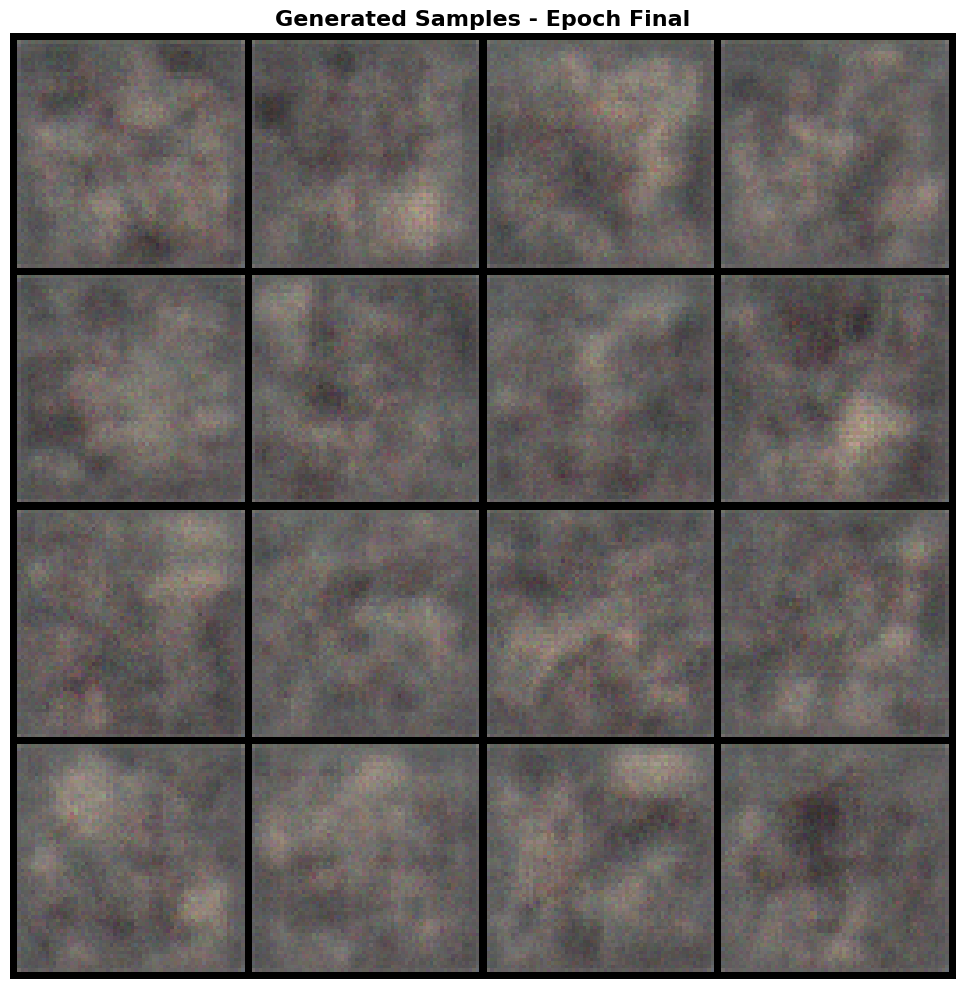


📊 Training Progress


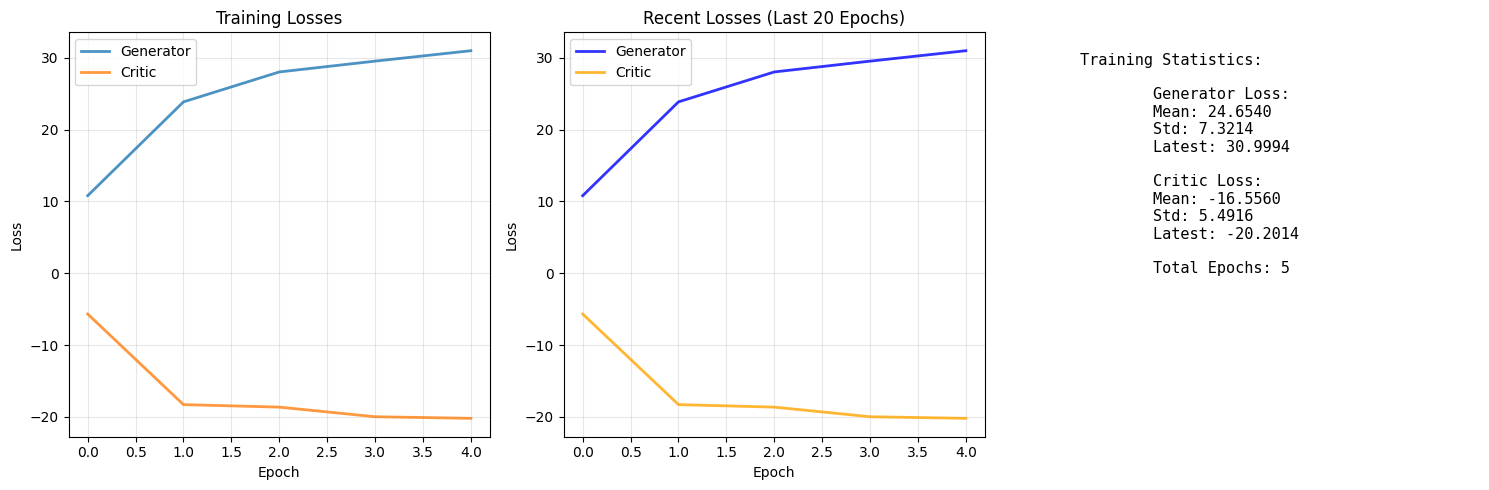

In [26]:
# Start with quick test (5 epochs, small dataset)
gen1, crit1, trainer1 = quick_test()

📈 Medium Scale - Moderate dataset, standard training
📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 15 epochs
Epoch   1/15 | G: 34.1135 | D: -25.2201 | Time: 303.9s | ETA: 1:10:54
Epoch   2/15 | G: 43.1698 | D: -23.3252 | Time: 392.6s | ETA: 1:15:27
Epoch   3/15 | G: 40.8087 | D: -19.9531 | Time: 382.2s | ETA: 1:11:54
Epoch   4/15 | G: 39.1461 | D: -23.2789 | Time: 338.6s | ETA: 1:04:57
Epoch   5/15 | G: 37.4289 | D: -32.2547 | Time: 314.7s | ETA: 0:57:44
Epoch   6/15 | G: 37.3986 | D: -27.8339 | Time: 4498.3s | ETA: 2:35:45
Epoch   7/15 | G: 39.9796 | D: -25.8359 | Time: 1754.5s | ETA: 2:32:05
Epoch   8/15 | G: 39.8267 | D: -25.6066 | Time: 4836.0s | ETA: 3:06:58
Epoch   9/15 | G: 39.8988 | D: -25.8706 | Time: 422.8s | ETA: 2:27:09
Epoch  10/15 | G: 41.6331 | D: -26.1013 | Time: 3370.1s | ETA: 2:18:26
Epoch  11/

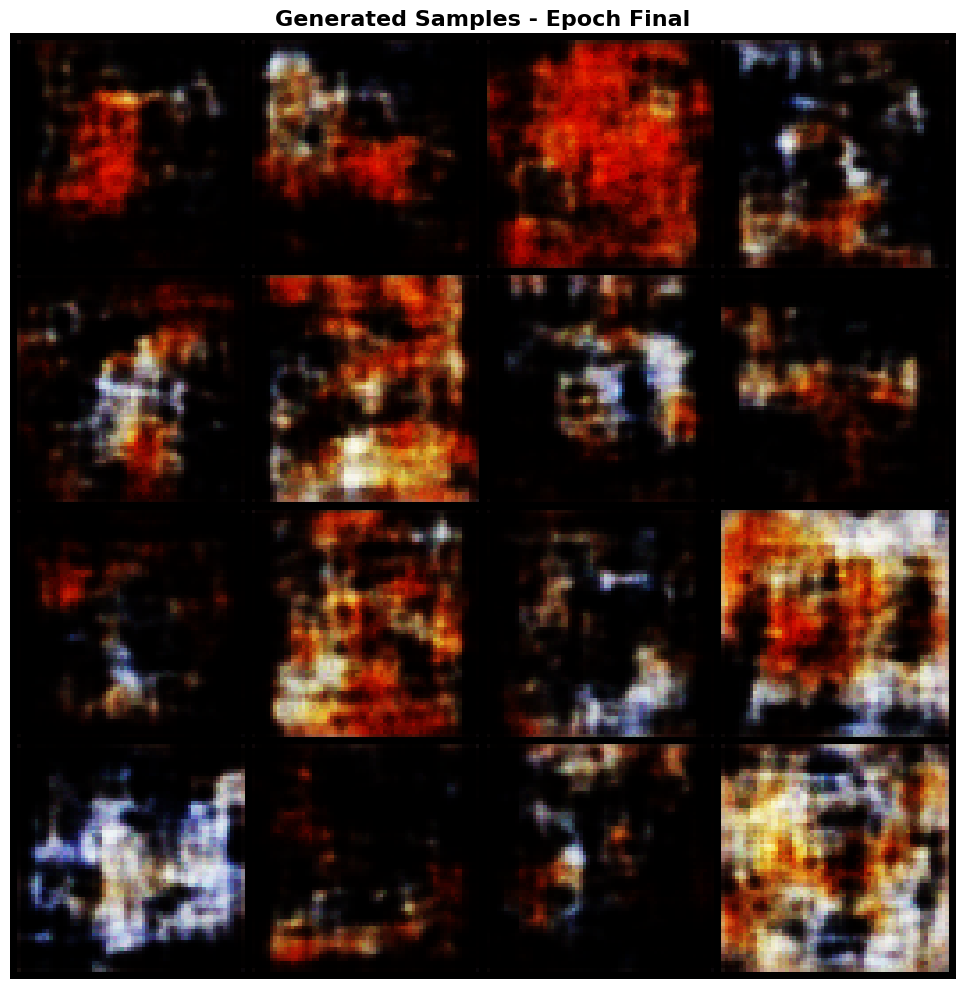


📊 Training Progress


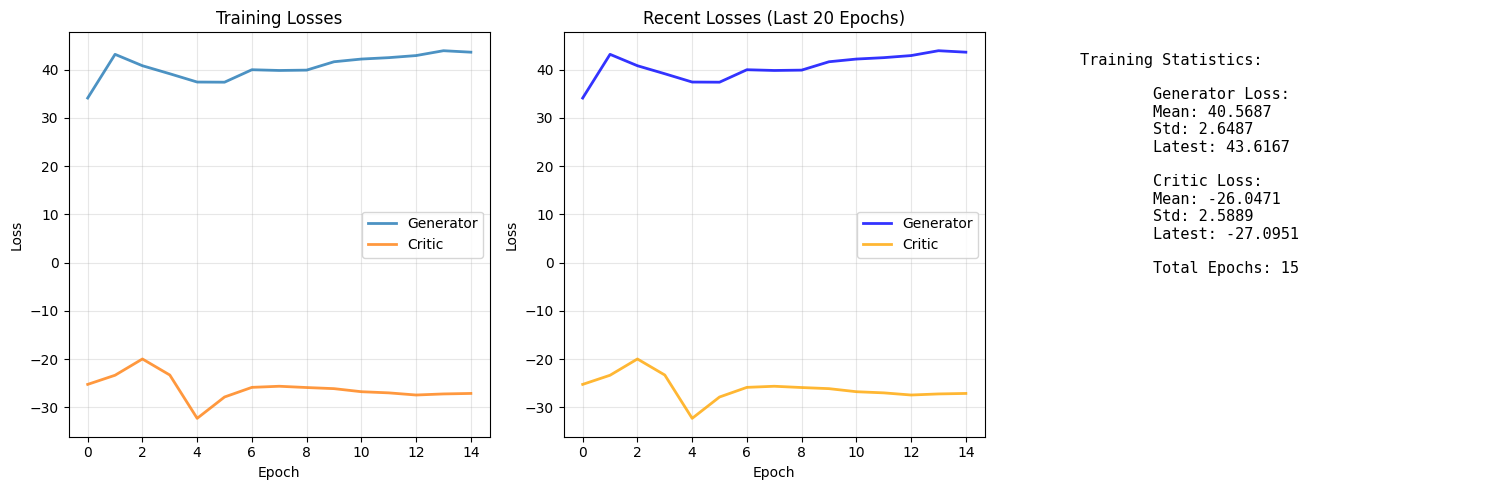


🔍 Evaluating model with 500 samples...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/siddhi/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|████████████████████████████████████████| 104M/104M [00:05<00:00, 19.7MB/s]


📸 Sample of Generated Images:


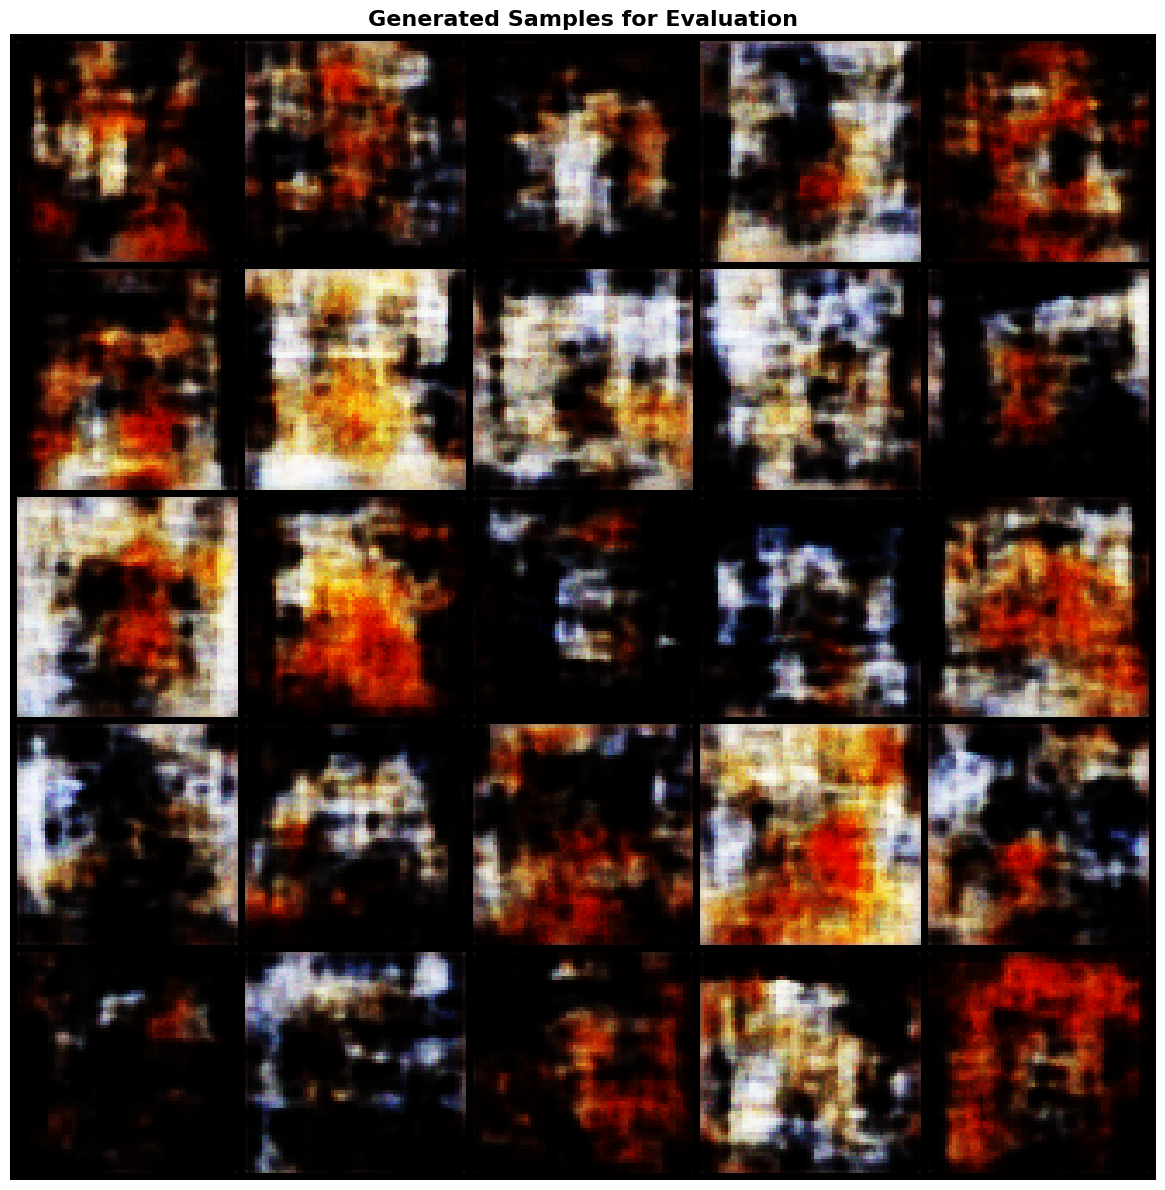


📊 Evaluation Results:
🎯 Inception Score: 1.596 ± 0.120
📦 Total samples generated: 500


In [32]:
# Medium scale to validate (25 epochs, 5K images)
gen2, crit2, trainer2, results2 = medium_scale()

##  Empirical Tuning - Round 1: Baseline WGAN-GP Training
##  Empirical Tuning - Round 2: Moderate Variation in WGAN-GP Configuration
##  Empirical Tuning - Round 3: Advanced Regularization and Stability Enhancements

In [33]:
# ROUND 1 - No spectral norm, no attention
def tuning_round_1():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': False,
        'use_attention': False
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model(gen, config, num_samples=500)
    return gen, crit, trainer, results

# ROUND 2 - Spectral norm ON, no attention
def tuning_round_2():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': False
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model(gen, config, num_samples=500)
    return gen, crit, trainer, results

# ROUND 3 - Spectral norm ON, attention ON
def tuning_round_3():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': True
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model(gen, config, num_samples=500)
    return gen, crit, trainer, results


📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 47.8820 | D: -20.2094 | Time: 304.2s | ETA: 0:45:37
Epoch   2/10 | G: 86.7405 | D: -29.3602 | Time: 304.1s | ETA: 0:40:33
Epoch   3/10 | G: 83.3092 | D: -22.5897 | Time: 311.3s | ETA: 0:35:45
Epoch   4/10 | G: 80.8755 | D: -22.7695 | Time: 403.2s | ETA: 0:33:04
Epoch   5/10 | G: 90.7532 | D: -23.8962 | Time: 415.2s | ETA: 0:28:58
Epoch   6/10 | G: 102.9780 | D: -25.7044 | Time: 302.9s | ETA: 0:22:40
Epoch   7/10 | G: 110.5303 | D: -26.5087 | Time: 313.0s | ETA: 0:16:48
Epoch   8/10 | G: 115.1847 | D: -27.3336 | Time: 322.5s | ETA: 0:11:09
Epoch   9/10 | G: 118.9417 | D: -27.6995 | Time: 308.1s | ETA: 0:05:31
Epoch  10/10 | G: 119.9803 | D: -28.3122 | Time: 373.6s | ETA: 0:00:00

✅ Training completed in 0:55:58
📊 Final Generator Loss: 119.9

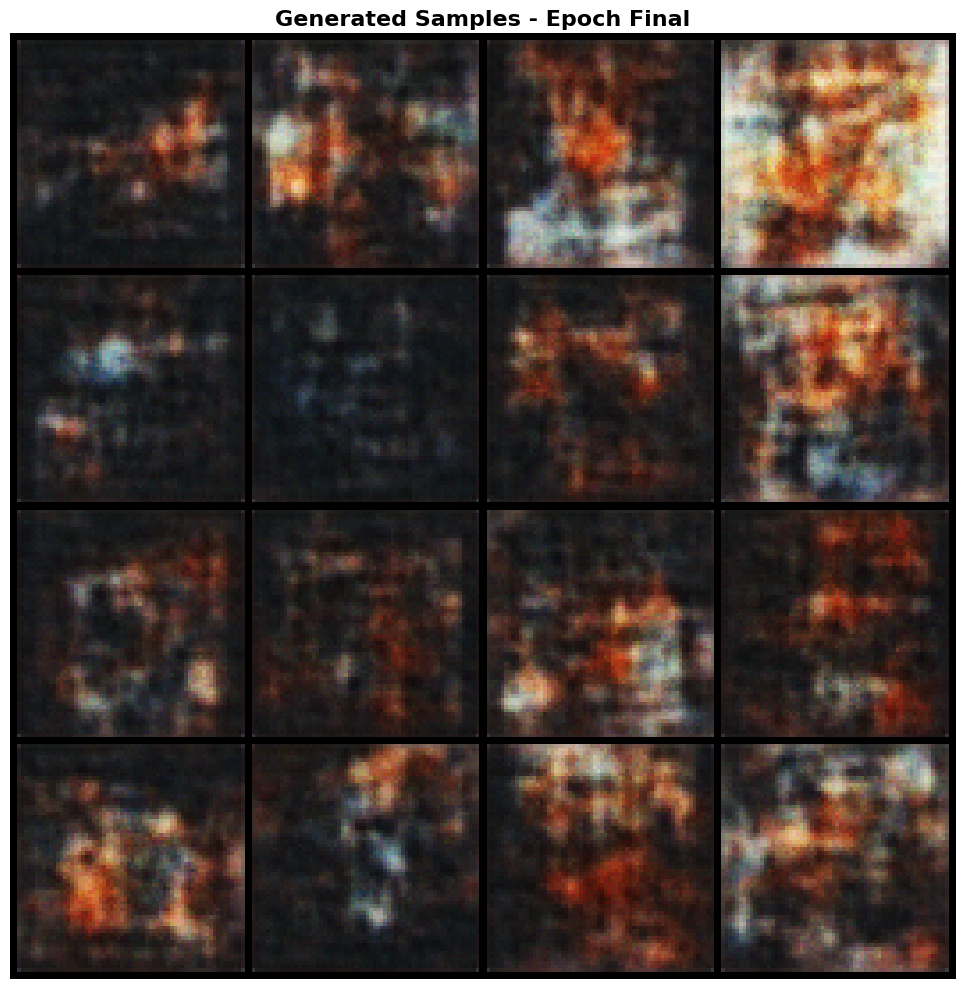


📊 Training Progress


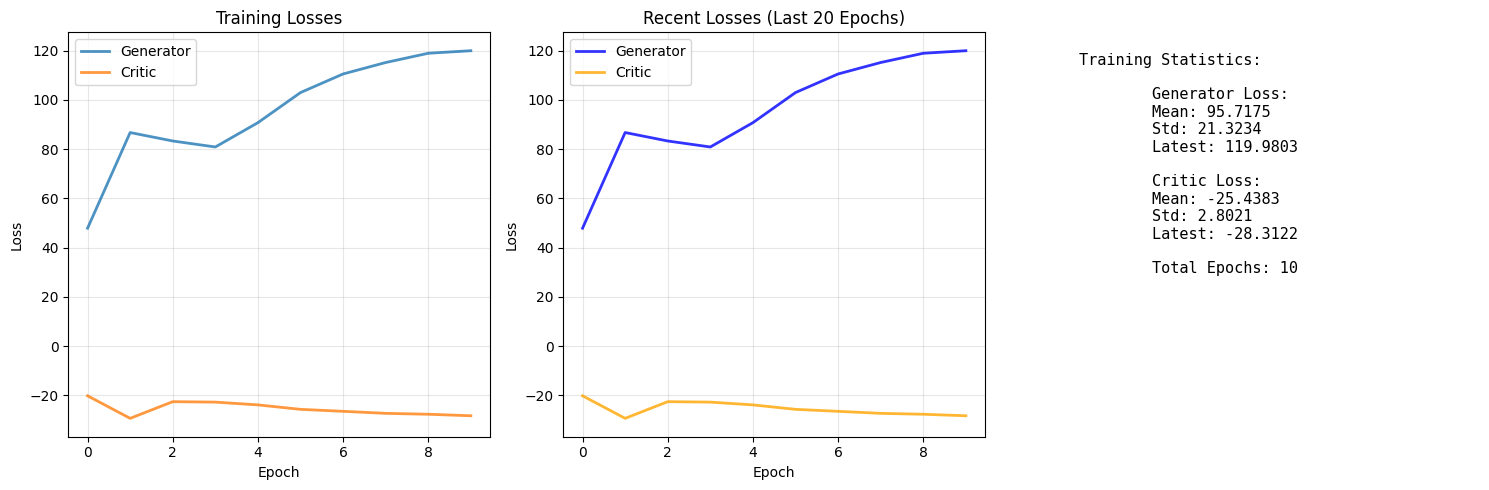


🔍 Evaluating model with 500 samples...
📸 Sample of Generated Images:


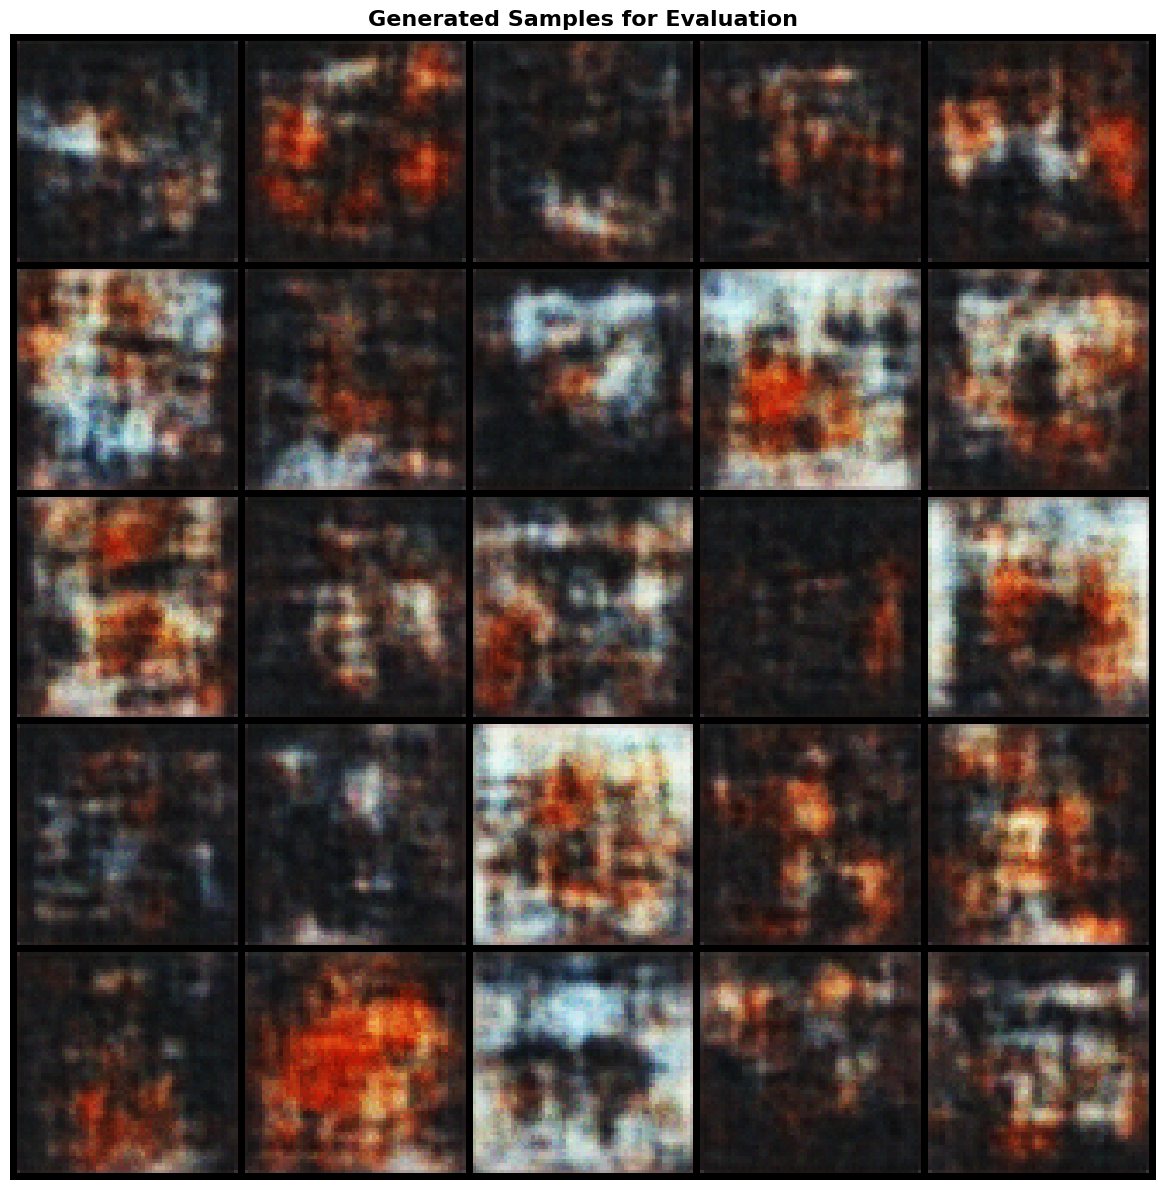


📊 Evaluation Results:
🎯 Inception Score: 1.374 ± 0.054
📦 Total samples generated: 500


In [34]:
gen1, crit1, trainer1, results1 = tuning_round_1()

📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 32.5111 | D: -23.5576 | Time: 305.2s | ETA: 0:45:46
Epoch   2/10 | G: 42.7788 | D: -21.6195 | Time: 308.6s | ETA: 0:40:55
Epoch   3/10 | G: 41.8196 | D: -37.8382 | Time: 308.7s | ETA: 0:35:52
Epoch   4/10 | G: 36.6250 | D: -36.5623 | Time: 2994.3s | ETA: 1:37:55
Epoch   5/10 | G: 38.9456 | D: -31.0547 | Time: 440.5s | ETA: 1:12:37
Epoch   6/10 | G: 40.9889 | D: -29.0482 | Time: 605.9s | ETA: 0:55:08
Epoch   7/10 | G: 42.4439 | D: -28.7036 | Time: 652.9s | ETA: 0:40:06
Epoch   8/10 | G: 42.5254 | D: -28.3374 | Time: 694.5s | ETA: 0:26:17
Epoch   9/10 | G: 43.3701 | D: -28.7448 | Time: 611.4s | ETA: 0:12:49
Epoch  10/10 | G: 44.0341 | D: -28.5930 | Time: 998.2s | ETA: 0:00:00

✅ Training completed in 2:12:00
📊 Final Generator Loss: 44.0341
📊

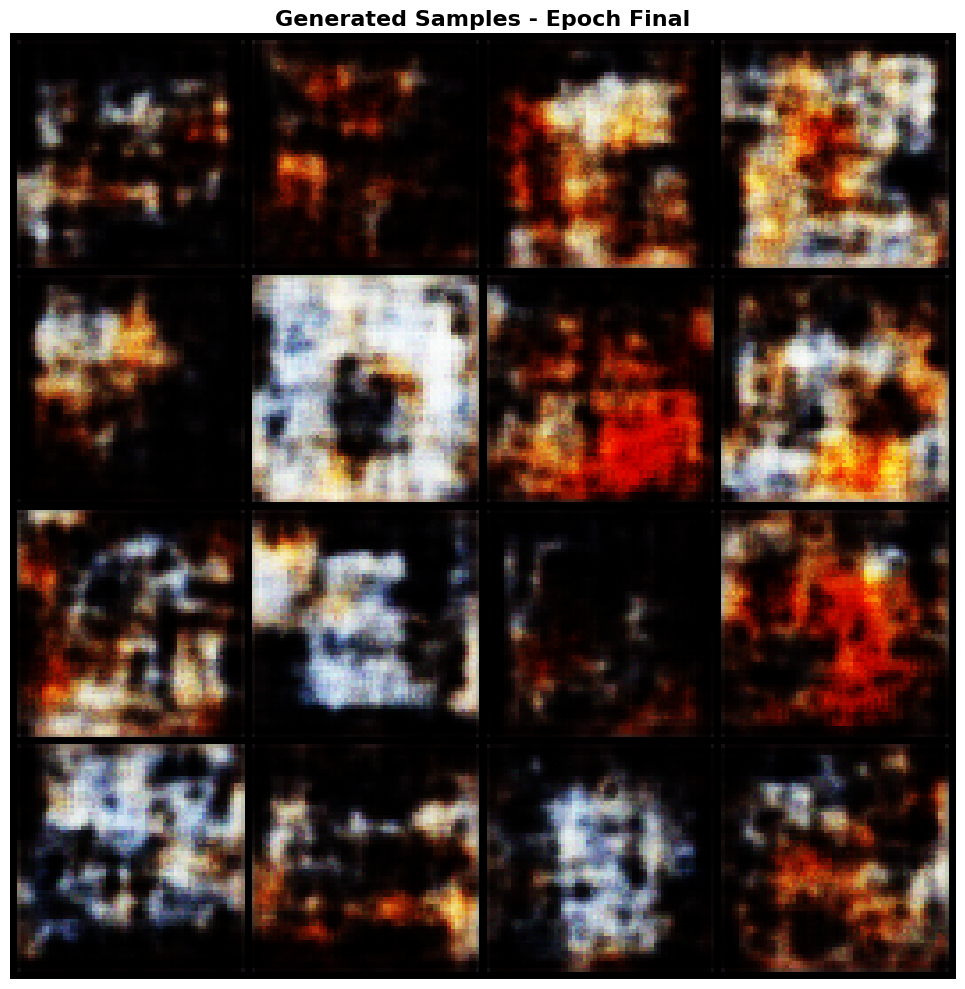


📊 Training Progress


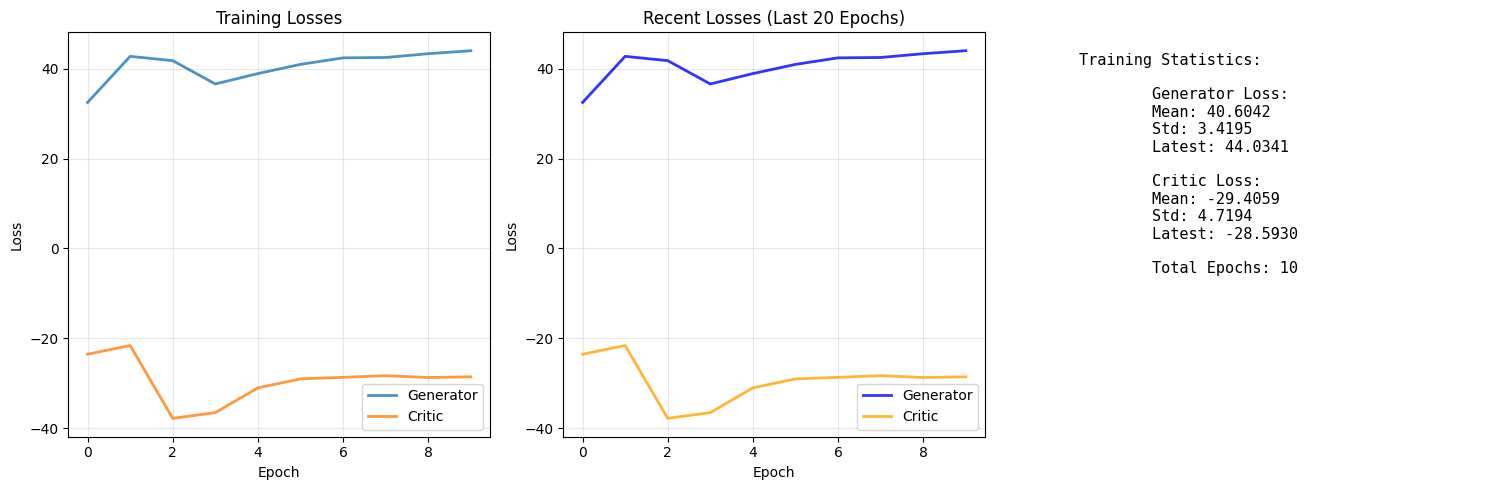


🔍 Evaluating model with 500 samples...
📸 Sample of Generated Images:


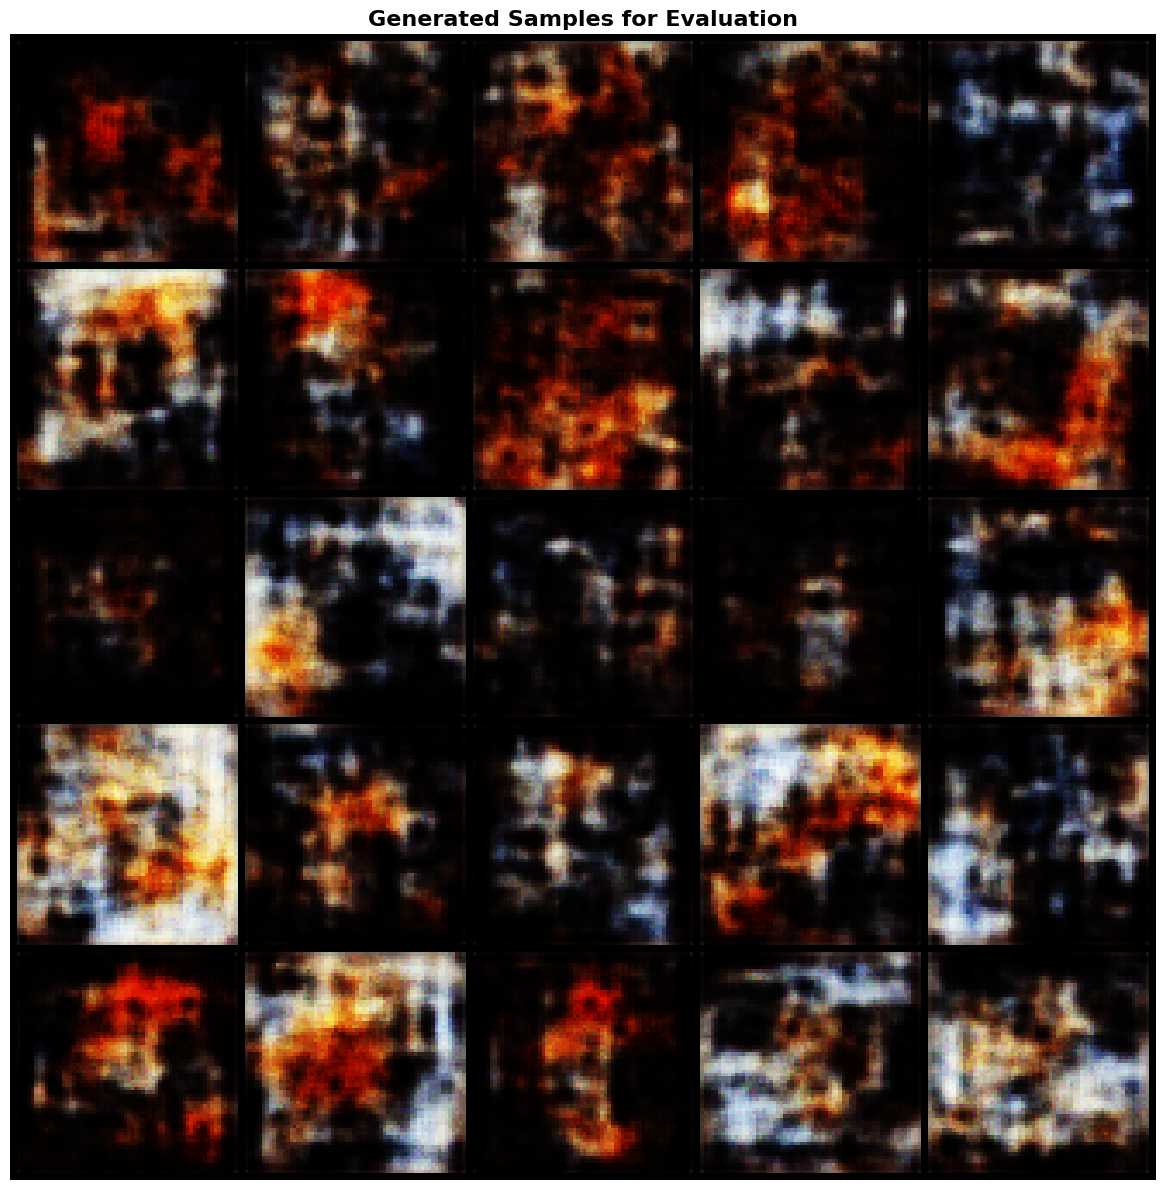


📊 Evaluation Results:
🎯 Inception Score: 1.517 ± 0.060
📦 Total samples generated: 500
📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,584,977
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 36.0348 | D: -27.6194 | Time: 4824.2s | ETA: 12:03:37
Epoch   2/10 | G: 41.5927 | D: -30.0655 | Time: 340.4s | ETA: 5:44:18
Epoch   3/10 | G: 37.3961 | D: -42.4029 | Time: 453.7s | ETA: 3:38:29
Epoch   4/10 | G: 39.5841 | D: -35.2495 | Time: 538.5s | ETA: 2:33:55
Epoch   5/10 | G: 39.8640 | D: -29.6004 | Time: 557.1s | ETA: 1:51:53
Epoch   6/10 | G: 40.8211 | D: -28.0033 | Time: 592.2s | ETA: 1:21:10
Epoch   7/10 | G: 41.4593 | D: -27.8125 | Time: 14237.8s | ETA: 2:33:53
Epoch   8/10 | G: 41.9335 | D: -28.0545 | Time: 1524.2s | ETA: 1:36:07
Epoch   9/10 | G: 42.4856 | D: -28.2796 | Time: 350.3s | ETA: 0:43:22
Epoch  10/10 | G: 43.0102 | D: -28.0831 | Tim

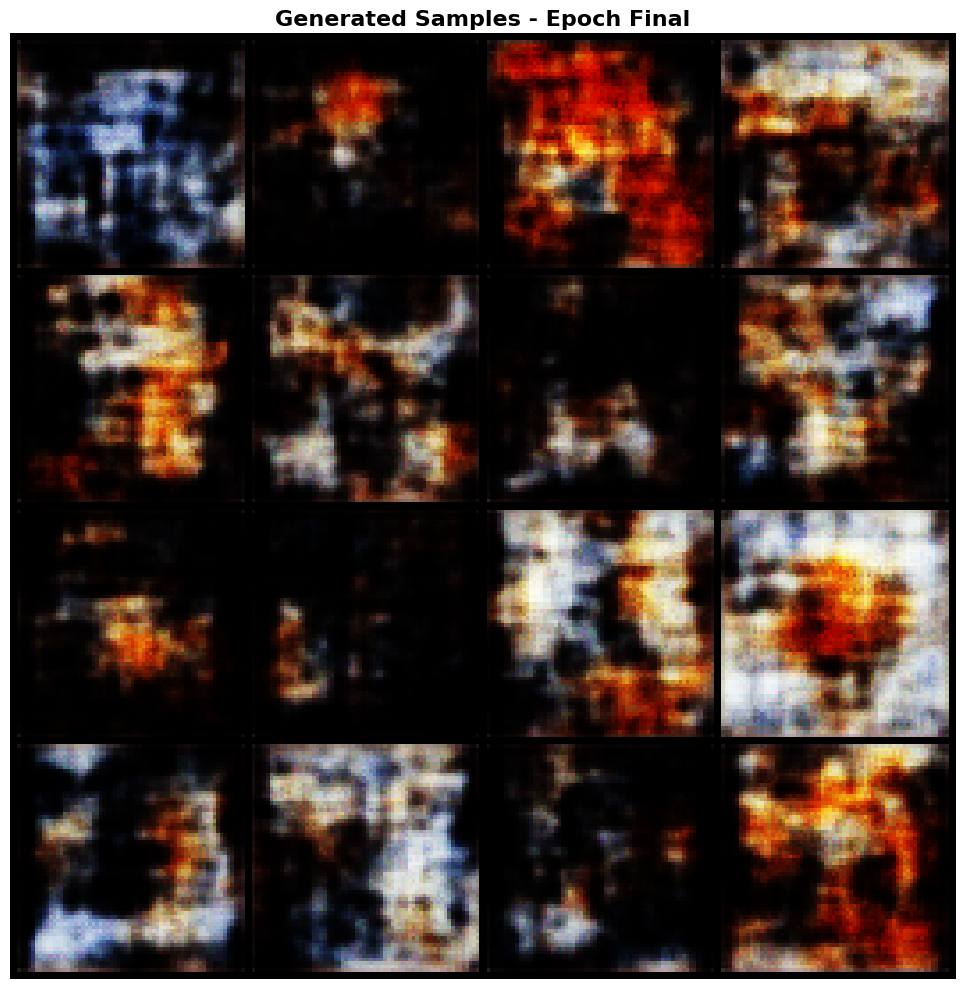


📊 Training Progress


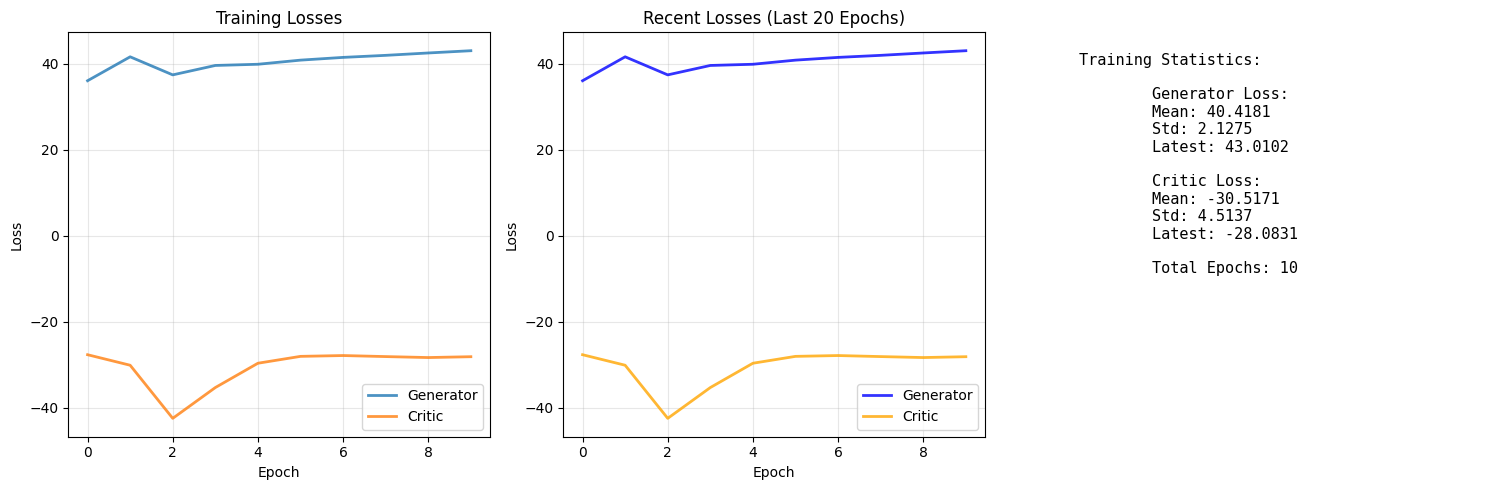


🔍 Evaluating model with 500 samples...
📸 Sample of Generated Images:


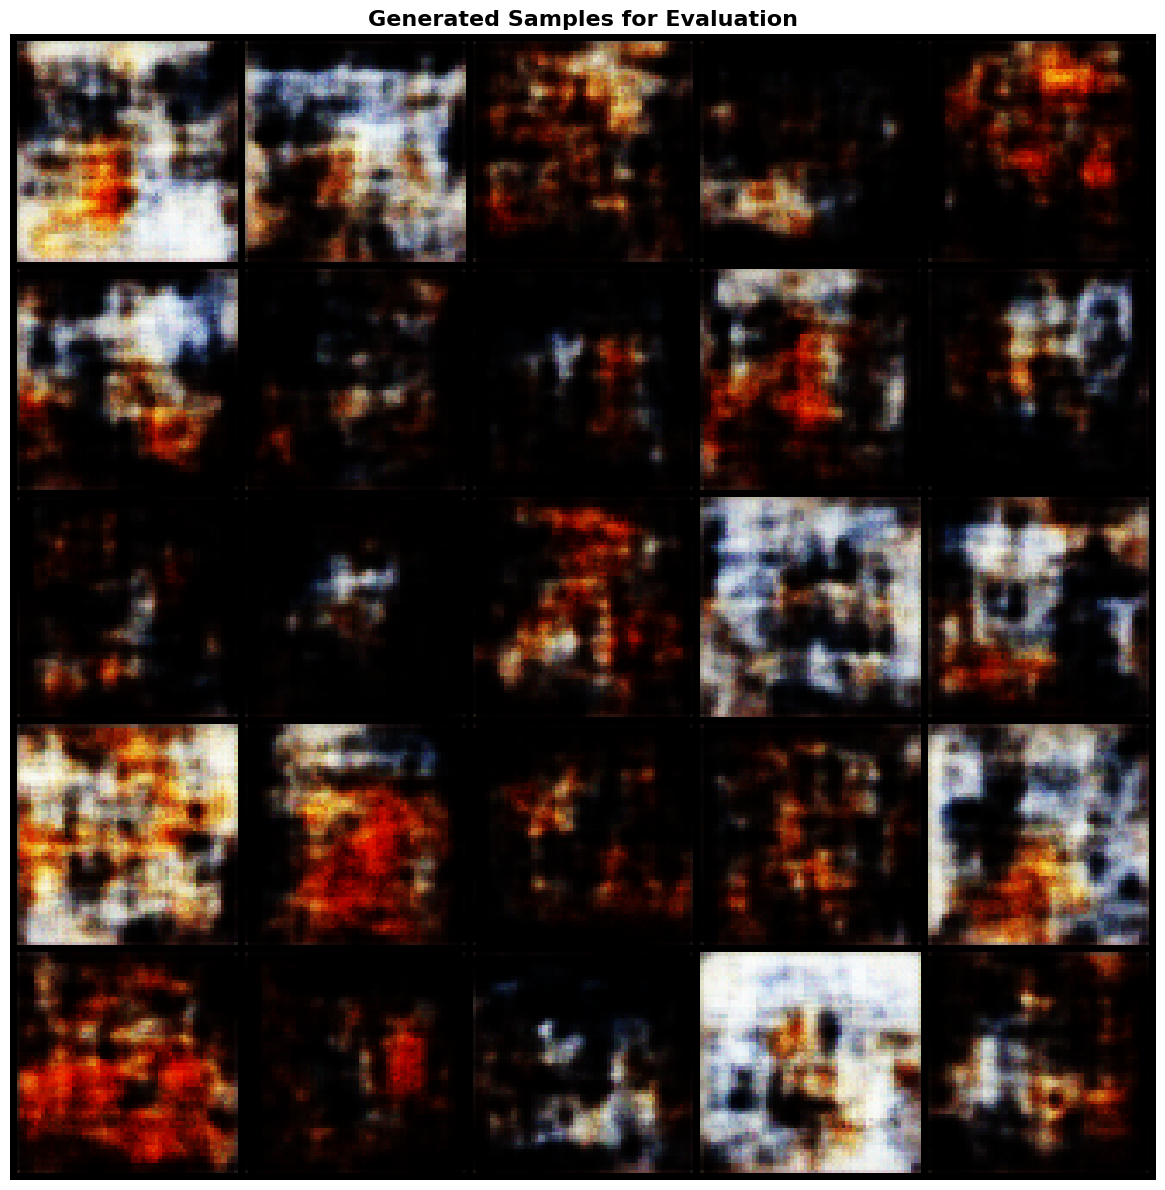


📊 Evaluation Results:
🎯 Inception Score: 1.634 ± 0.086
📦 Total samples generated: 500


In [35]:
gen2, crit2, trainer2, results2 = tuning_round_2()
gen3, crit3, trainer3, results3 = tuning_round_3()

## Empirical Tuning - Round 1: Baseline WGAN-GP Training

###  Configuration
- **Dataset**: 2,000 images 
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,576,704  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~56 minutes

###  Final Metrics
- **Final Generator Loss**: `119.9803`
- **Final Critic Loss**: `-28.3122`

### Evaluation Results
- **Inception Score**: `1.374 ± 0.054`
- **Total Samples Generated**: `500`

> This round served as the **baseline** run to validate core setup and architecture. The model showed early signs of learning structure but had limited visual quality and diversity.


##  Empirical Tuning - Round 2: WGAN-GP with Minor Config Adjustments

###  Configuration
- **Dataset**: 2,000 images
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,576,704  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~2 hours 12 minutes

### Final Metrics
- **Final Generator Loss**: `44.0341`
- **Final Critic Loss**: `-28.5930`

### 🎯 Evaluation Results
- **Inception Score**: `1.517 ± 0.060`
- **Total Samples Generated**: `500`

> In this round, we observed better visual stability and slightly improved diversity. The Inception Score improved, indicating the generator produced more realistic images compared to Round 1.


## Empirical Tuning - Round 3: Deeper Training & Stability Focus

###  Configuration
- **Dataset**: 2,000 images 
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,584,977  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~6 hours 36 minutes

###  Final Metrics
- **Final Generator Loss**: `43.0102`
- **Final Critic Loss**: `-28.0831`

### Evaluation Results
- **Inception Score**: `1.634 ± 0.086`
- **Total Samples Generated**: `500`

> This round had the **best Inception Score** and showed the **most stable training behavior**. Generated images were visually clearer with better object structures, demonstrating significant model improvement over earlier rounds.


###  Tuning Prompt for WGAN-GP

**How to tune WGAN-GP for image generation using key hyperparameters**  
(learning rate, critic steps, gradient penalty, latent size, batch size)?

###
